📂 Cargando grafo desde archivo local...


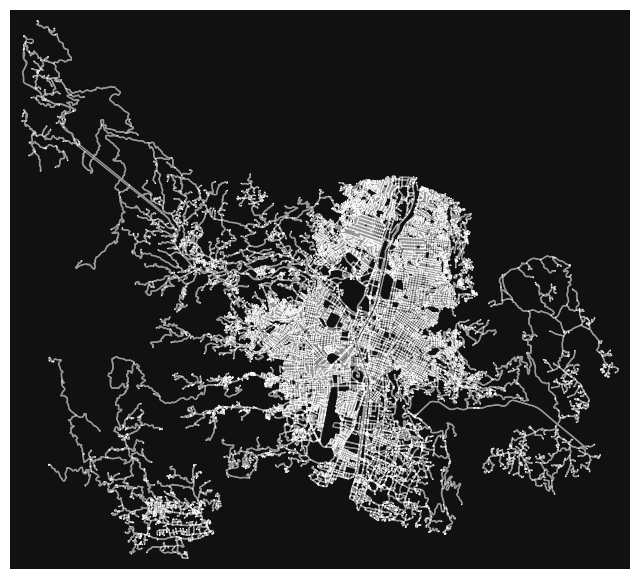

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [83]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import os
place_name = "Medellin, Colombia"
file_path = "medellin_drive.graphml"

if os.path.exists(file_path):
    print("📂 Cargando grafo desde archivo local...")
    G = ox.load_graphml(file_path)
else:
    print("🌍 Descargando grafo desde OpenStreetMap...")
    G = ox.graph_from_place(place_name, network_type="drive", simplify=True)
    ox.save_graphml(G, file_path)
    print("💾 Grafo guardado localmente.")

ox.plot_graph(G, node_size=1, node_color="white")



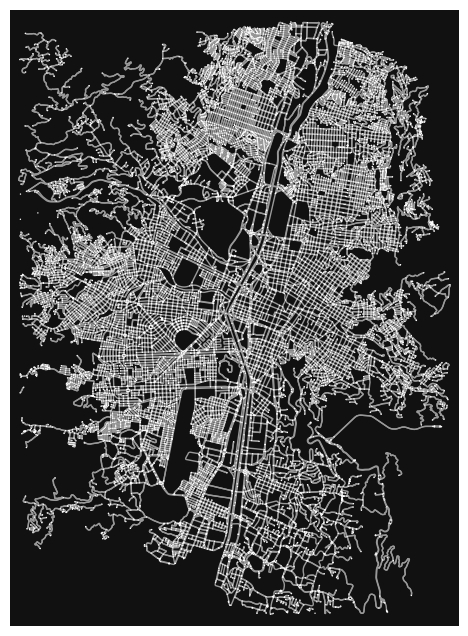

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [84]:
#Filtramos un poco la región para poderla hacer un poco más manejable
import numpy as np
north = 6.312
south = 6.182
east  = -75.531
west  = -75.626
nodos=[n for n in G.nodes if G.nodes[n]['x']>=west and G.nodes[n]['x']<=east and G.nodes[n]['y']>=south and G.nodes[n]['y']<=north]
G2=G.subgraph(nodos)
ox.plot_graph(G2, node_size = 1, node_color = "white")

In [85]:
#Parámetros del problema
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import contextily as cx
cap=20 #Número de niños por bus
N=400 #Número de niños
ni=list(np.random.choice(G2.nodes, size=N)) #Nodos donde los niños se ubican
#ni está escrito en valores enteros de identificación del nodo, no es indices. 

r_origen=(-75.58683269546758, 6.243283526198216)
xi=[G2.nodes[n]['x'] for n in ni]
yi=[G2.nodes[n]['y'] for n in ni]

x=[G2.nodes[n]['x'] for n in G2.nodes]
y=[G2.nodes[n]['y'] for n in G2.nodes]
n=list(G2.nodes)

dist=[(xj-r_origen[0])**2+(yj-r_origen[1])**2 for xj,yj in zip(x,y)]
origen=n[np.argmin(dist)]
ni.append(origen)
xi.append(r_origen[0])
yi.append(r_origen[1])
ni=[int(n) for n in ni]
import geopandas as gpd
import contextily as ctx

latMin=south
latMax=north
lonMin=west
lonMax=east


In [86]:
#Cálculo de las matrices de origen destino y distancias entre todos los puntos
from tqdm import tqdm
dist={}
ruta={}
for i in tqdm(range(len(ni))):
  distancias = nx.single_source_dijkstra_path_length(G2,source=ni[i], weight="length")
  for j in range(len(ni)):
    if(ni[j] in distancias.keys()):
      dist[(ni[i],ni[j])]=float(distancias[ni[j]])
    else:
      dist[(ni[i],ni[j])]=float('inf')

100%|██████████| 401/401 [00:35<00:00, 11.16it/s]


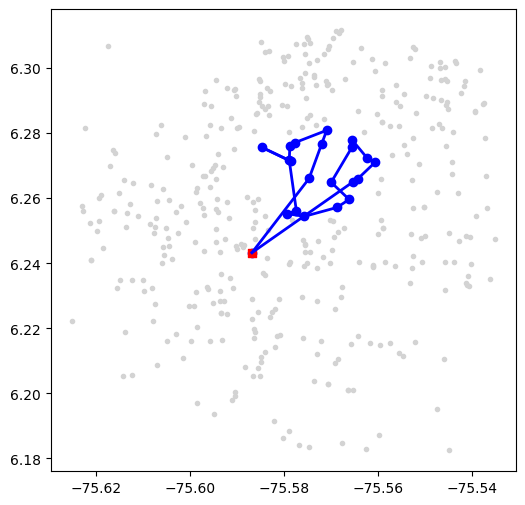

In [87]:
import matplotlib.colors as mcolors
def generate_distinct_colors(n, saturation=0.75, value=0.9):
    """
    Genera n colores bien separados visualmente.
    Retorna lista en formato HEX.
    """
    hues = np.linspace(0, 1, n, endpoint=False)
    colors = [
        mcolors.hsv_to_rgb((h, saturation, value))
        for h in hues
    ]
    return [mcolors.to_hex(c) for c in colors]

#Proceso de hacer clusters, pero a partir de una posición fija xo, yo y tomando elipses o círculos alrededor hasta que se llenen los buses
from networkx.algorithms.approximation import traveling_salesman_problem
xmax, xmin=np.max(xi), np.min(xi)
ymax, ymin=np.max(yi), np.min(yi)
xo,yo=np.random.uniform(low=[xmin, ymin], high=[xmax, ymax], size=(2))
index={n:i for i,n in enumerate(ni)}
#print(index)
def cluster_around_point(xi, yi, xo, yo, N, dibujar=False):
    """
    Clusteriza puntos alrededor de un punto fijo (xo, yo) hasta llenar la capacidad N.
    Retorna los índices de los puntos asignados al cluster.
    """
    distancias = np.sqrt((np.array(xi) - xo)**2 + (np.array(yi) - yo)**2)
    sorted_indices = list(np.argsort(distancias)[0:N]) #Estos son los nodos que quedaron en el cluster
    #Ahora debo construir la matriz de distancias considerando también el origen y destino de las rutas
    sorted_indices=[ni[int(n)] for n in sorted_indices]
    #print(len(sorted_indices))
    sorted_indices.append(origen)

    #print(sorted_indices)
    #Ahora debo usar un algoritmo de TSP para encontrar la ruta óptima para este cluster
    G_cluster = nx.DiGraph()  
    for i in range(len(sorted_indices)):
        for j in range(len(sorted_indices)):
            #print((sorted_indices[i], sorted_indices[j]))
            G_cluster.add_edge(i, j, weight=dist[(sorted_indices[i], sorted_indices[j])])
    tour = traveling_salesman_problem(G_cluster, cycle=True, weight='weight', method=nx.algorithms.approximation.greedy_tsp)
    costo=0
    for i in range(len(tour)-1):
        n1=sorted_indices[tour[i]]
        n2=sorted_indices[tour[i+1]]
        costo += dist[(n1, n2)] 
        
    if(dibujar):
        plt.figure(figsize=(6,6)) 
        ax=plt.subplot(1,1,1)
        ax.scatter(xi[:-1], yi[:-1], marker='.', color='lightgray', label='Niños')
        xc, yc=[],[]
        xc=[xi[index[i]] for i in sorted_indices]
        yc=[yi[index[i]] for i in sorted_indices] 
        ax.scatter(xc, yc, marker='o', color='blue', label='Cluster')
        ax.scatter(xi[-1], yi[-1], marker='s', color='red', label='Destino')
        for i in range(len(tour)-1):
            n1=sorted_indices[tour[i]]
            n2=sorted_indices[tour[i+1]]
            plt.plot([xi[index[n1]], xi[index[n2]]], [yi[index[n1]], yi[index[n2]]], color='blue', linewidth=2)
    return sorted_indices, costo, tour
cluster_indices, costo, tour = cluster_around_point(xi, yi, xo, yo, N=cap, dibujar=True)
#print(cluster_indices, costo, tour)

In [88]:
from tqdm import tqdm   
N=1000
cap=20
d=np.sqrt((xmax-xmin)*(ymax-ymin)/N)
xo, yo=np.meshgrid(np.arange(xmin, xmax, d), np.arange(ymin, ymax, d))
clusters=[]
for x0, y0 in tqdm(zip(xo.flatten(), yo.flatten())):
    cluster_indices, costo, tour = cluster_around_point(xi, yi, x0, y0, N=cap, dibujar=False)
    if(costo<float('inf')):
        clusters.append((cluster_indices, costo, tour))

1026it [00:01, 820.36it/s]


In [89]:
clusters[100]

([5917169655,
  3613643531,
  1842190644,
  9365380164,
  416638597,
  1842190645,
  344479303,
  9371997730,
  343600926,
  309028467,
  9857457488,
  4072437730,
  343535126,
  5483069112,
  9728708667,
  1839319064,
  4070549575,
  12836482208,
  12836482208,
  9392689013,
  1559490216],
 41466.0509938086,
 [0, 1, 4, 6, 7, 9, 10, 13, 11, 19, 14, 12, 2, 5, 15, 17, 18, 8, 3, 16, 20, 0])

In [90]:
#Problema de set cover con los clusters encontrados. 
import pulp
prob=pulp.LpProblem("SetCover", pulp.LpMinimize)
cob=[]
cluster_vars = [pulp.LpVariable(f'cluster_{i}', cat='Binary') for i in range(len(clusters))]
kids_vars=[pulp.LpVariable(f'kid_{i}', cat='Binary') for i in range(len(ni)-1)]
num=0
for i in range(len(ni)-1):
    cobertura=np.sum([1 for j in range(len(clusters)) if ni[i] in clusters[j][0]])
    cob.append(cobertura)
    if(cobertura==0):
        print(f"Niño {ni[i]} no cubierto por ningún cluster")
    else:
        prob += pulp.lpSum(cluster_vars[j] for j in range(len(clusters)) if ni[i] in clusters[j][0]) >= kids_vars[i], f"Cover_{i}"
        num+=1
prob+= pulp.lpSum(cluster_vars[j] * clusters[j][1] for j in range(len(clusters))), "TotalCost"
prob+= pulp.lpSum(kids_vars[j] for j in range(len(kids_vars)))>=0.95*num, "CoverageConstraint"
print(prob.solve())
clusters_usados=[]
for v in prob.variables():
    if v.varValue > 0:
        print(v.name, "=", v.varValue)
        idx=int(v.name.split('_')[1])
        clusters_usados.append(clusters[idx])

Niño 9408486569 no cubierto por ningún cluster
Niño 833662046 no cubierto por ningún cluster
Niño 5860796384 no cubierto por ningún cluster
Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/carlos-hincapie/python/busopt/.venv/lib/python3.12/site-packages/pulp/apis/../solverdir/cbc/linux/i64/cbc /tmp/e7433a2ef33e4d9983ec5e8be2386c79-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /tmp/e7433a2ef33e4d9983ec5e8be2386c79-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 403 COLUMNS
At line 21218 RHS
At line 21617 BOUNDS
At line 22854 ENDATA
Problem MODEL has 398 rows, 1236 columns and 17506 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 443120 - 0.04 seconds
Cgl0004I processed model has 398 rows, 1186 columns (1186 integer (1153 of which binary)) and 16563 elements
Cbc0038I Initial state - 266 integers unsatisfied sum - 3

KeyboardInterrupt: 

In [ ]:
for name, constraint in prob.constraints.items():
    if(constraint.slack!=0):
        print(f"{name}: slack = {constraint.slack}")

Cover_16: slack = -1.0
Cover_27: slack = -1.0
Cover_29: slack = -1.0
Cover_32: slack = -1.0
Cover_37: slack = -1.0
Cover_38: slack = -1.0
Cover_39: slack = -1.0
Cover_52: slack = -1.0
Cover_77: slack = -1.0
Cover_83: slack = -1.0
Cover_104: slack = -1.0
Cover_108: slack = -1.0
Cover_133: slack = -1.0
Cover_180: slack = -1.0
Cover_184: slack = -1.0
Cover_196: slack = -1.0
Cover_204: slack = -1.0
Cover_215: slack = -1.0
Cover_231: slack = -1.0
Cover_242: slack = -1.0
Cover_258: slack = -1.0
Cover_284: slack = -1.0
Cover_285: slack = -1.0
Cover_290: slack = -1.0
Cover_306: slack = -1.0
Cover_308: slack = -1.0
Cover_333: slack = -1.0
Cover_337: slack = -1.0
Cover_369: slack = -1.0
Cover_377: slack = -1.0
CoverageConstraint: slack = -0.7000000000000455


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


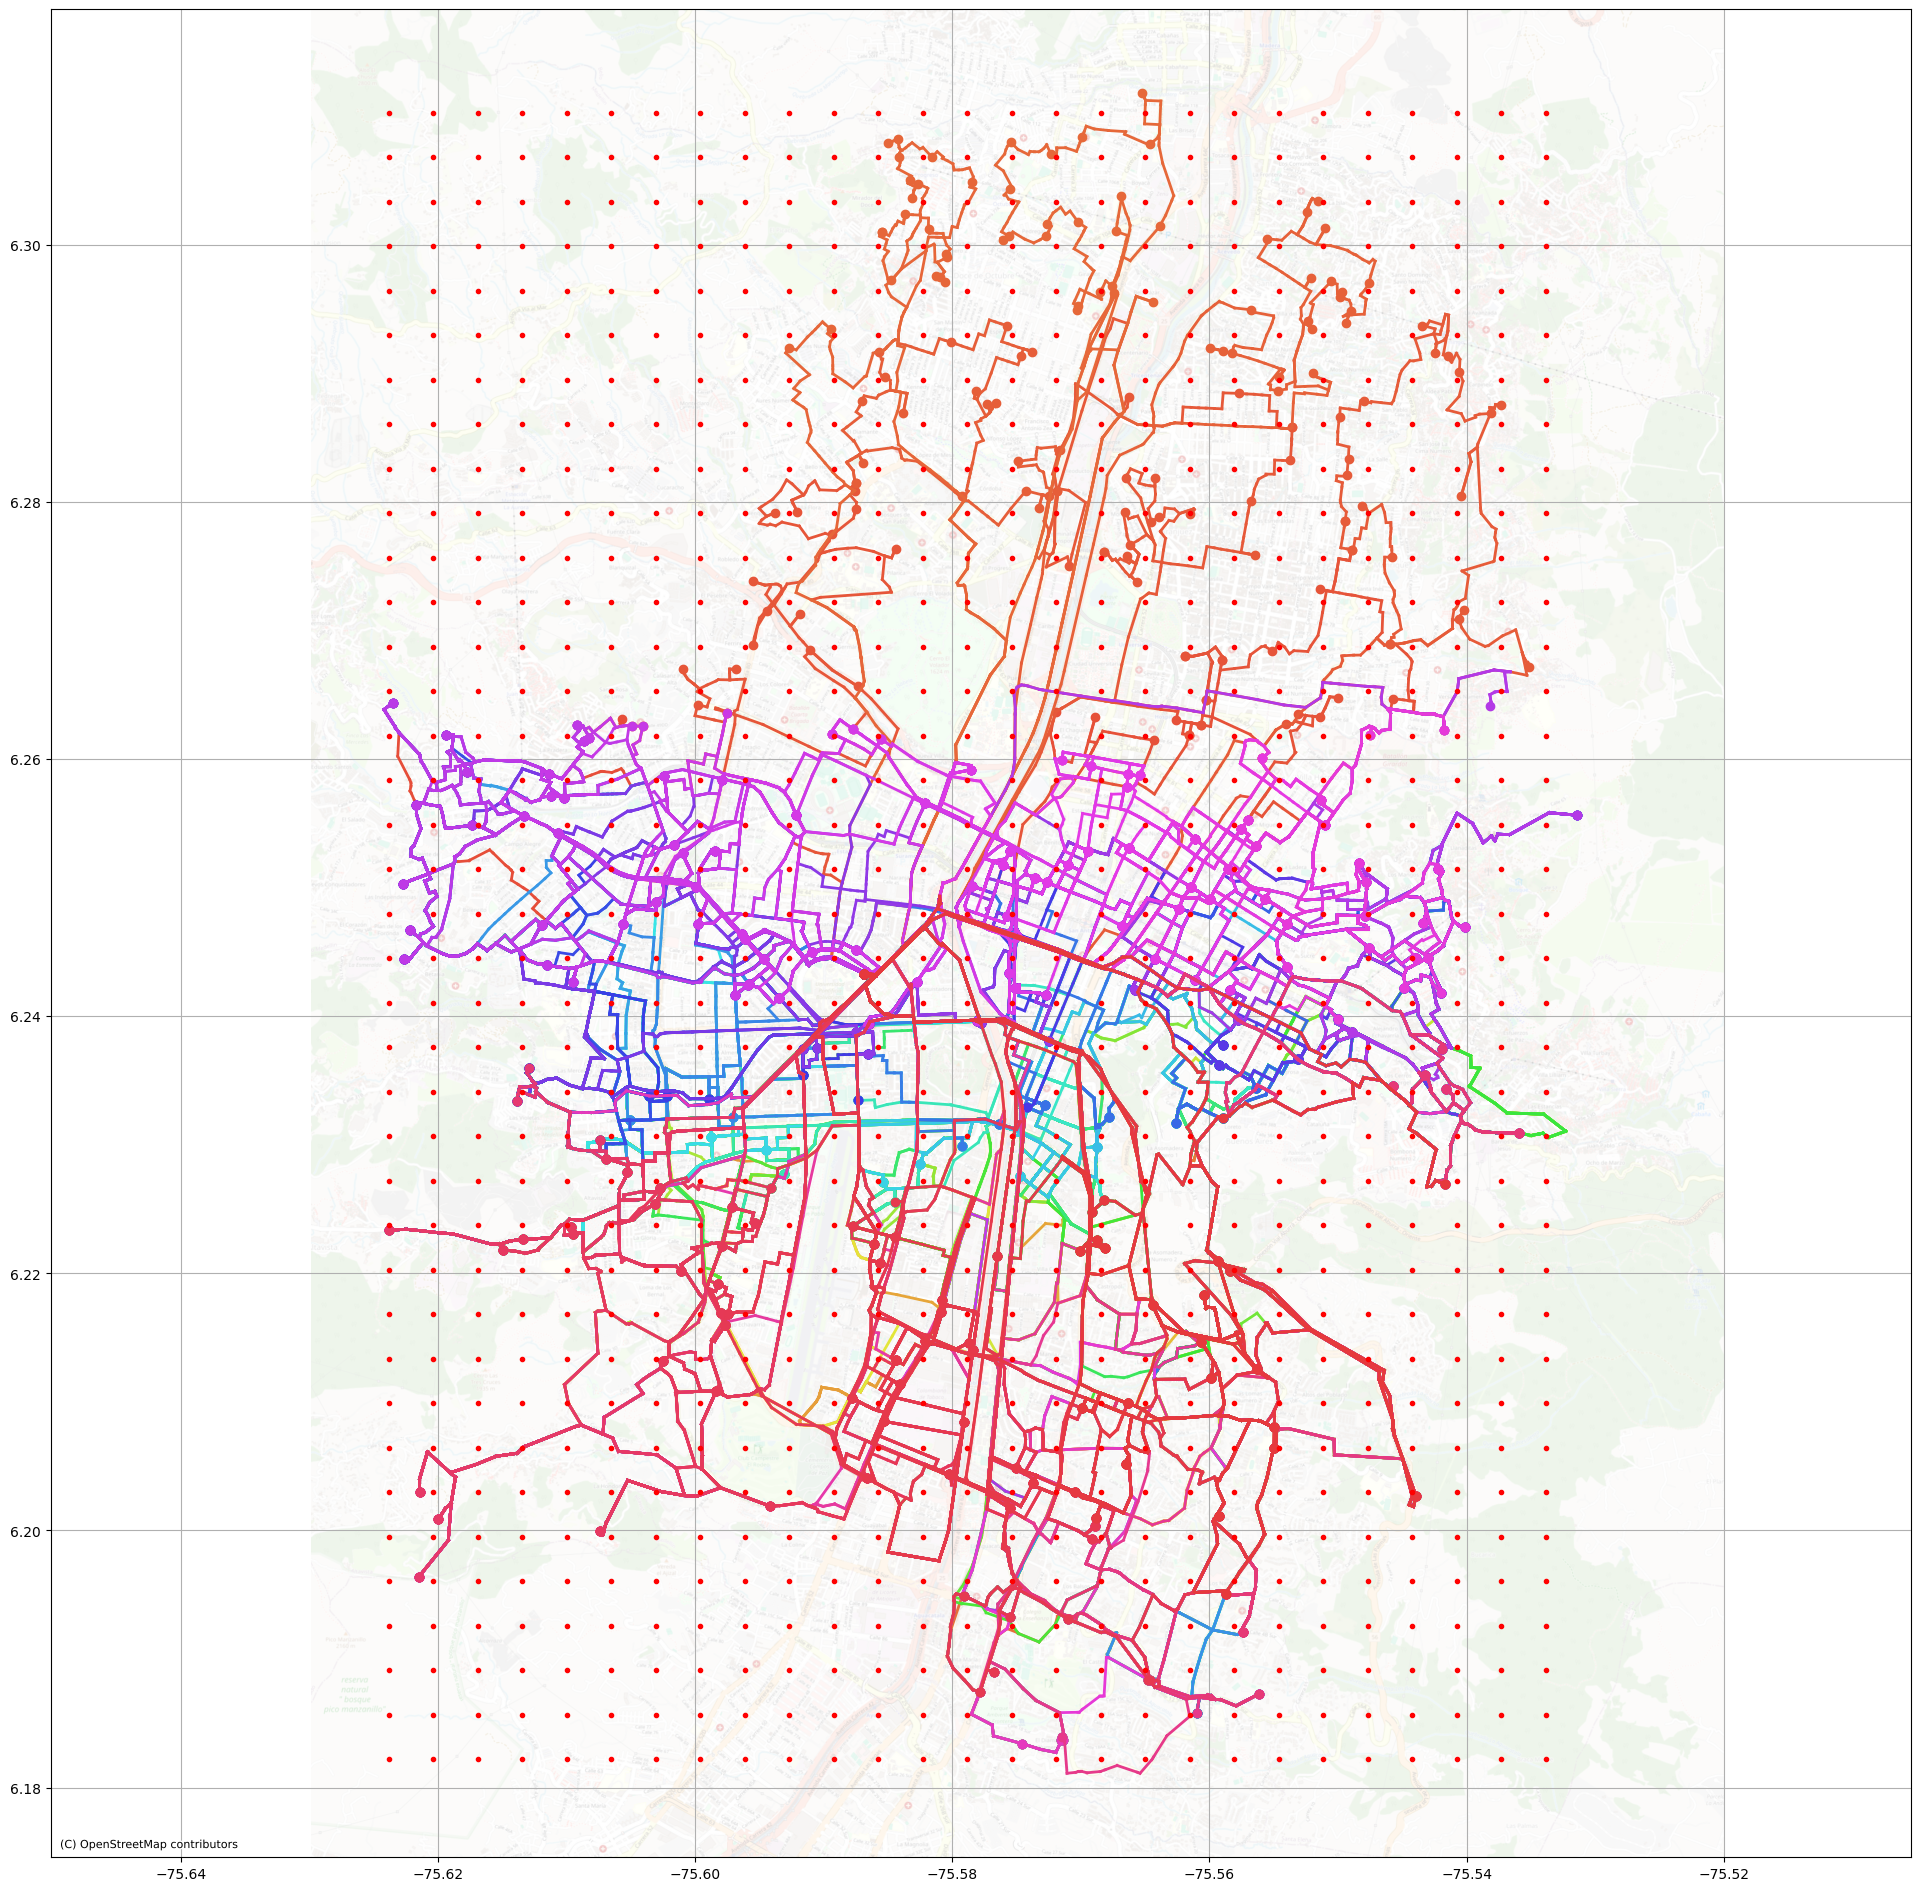

In [ ]:
co = generate_distinct_colors(len(clusters_usados))
plt.figure(figsize=(24,24))
ax=plt.subplot(1,1,1)
ind=0
for cluster_indices, costo, tour in clusters_usados:
  xc, yc=[],[]
  xc=[xi[index[i]] for i in cluster_indices]
  yc=[yi[index[i]] for i in cluster_indices]
  plt.plot(xc, yc, 'o', color=co[ind])
  tour2=[cluster_indices[i] for i in tour]
  for j in range(len(tour2)-1):
    if(nx.has_path(G, source=tour2[j], target=tour2[j+1])):
      camino=nx.dijkstra_path(G, source=tour2[j], target=tour2[j+1], weight='length')
      for k in range(len(camino)-1):
        plt.plot([G.nodes[camino[k]]['x'], G.nodes[camino[k+1]]['x']], [G.nodes[camino[k]]['y'], G.nodes[camino[k+1]]['y']], color=co[ind], linewidth=2)
        
  ind+=1
xcl=xo.flatten()
ycl=yo.flatten()
plt.plot(xcl, ycl, '.r')
plt.axis('equal')
plt.grid()
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=15, crs='EPSG:4326', alpha=0.2)
plt.savefig("rutas.png", dpi=300)

In [103]:
L={}
for i in ni: 
    for j in ni:
        if(i!=j):
            if(dist[(i,j)]==float('inf')):
                #print(f"No hay camino entre {i} y {j}")
                if(i not in L.keys()):
                    L[i]=0
                if(j not in L.keys()):
                    L[j]=0
                L[i]+=1
                L[j]+=1
permanecen=[]
for k,v in L.items():
    if(v)>10:
        print(f"Nodo {k} no tiene camino a {v} nodos")
    else:
        permanecen.append(k)

Nodo 9408486569 no tiene camino a 392 nodos
Nodo 833662046 no tiene camino a 394 nodos
Nodo 5860796384 no tiene camino a 788 nodos


Grafo 2 conectado:  True


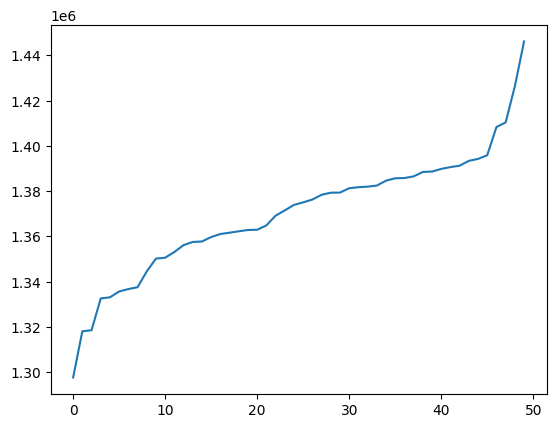

In [104]:
#Variables que necesito
#ni, nodos, xi, yi, coordenadas de los nodos
#dist: diccionario con las distancias entre cada par de nodos, incluyendo el origen y destino.
#cap: capacidades de los buses

#Voy a extraer un grafo con los nodos que estén realmente conectados entre si
# Obtener componentes fuertemente conectadas#
#Grafo grande, completo
G=nx.DiGraph()
for x,y,n in zip(xi, yi, ni):
    G.add_node(n, x=x, y=y)
for i in range(len(ni)):
    for j in range(len(ni)):
        if(i!=j and (ni[i],ni[j]) in dist.keys() and dist[(ni[i], ni[j])] != float('inf')):
            G.add_edge(ni[i], ni[j], weight=dist[(ni[i], ni[j])])
G2 = G.subgraph(permanecen).copy()
print('Grafo 2 conectado: ',nx.is_strongly_connected(G2))

class solucion:
  def __init__(self, cromosoma=[], nbuses=20):
    self.G2=G2.copy()
    self.n=len(G2.nodes)-1 #Número de niños, sin contar el destino
    self.ni=list(G2.nodes)
    self.nbuses=nbuses
    if(len(cromosoma)==0):
      self.X=np.random.randint(size=self.n, low=0, high=self.nbuses)
    else:
      self.X=cromosoma.copy()
    self.Z=self.f() #Z es la variable que representa el valor de fitnness de la solución

  def f(self, mostrar=False): #Función de Fitness
    #origen es el nodo origen, ahora los nodos tienen identificador como el número del nodo el OSM
    #Se debe solucionar la ruta óptima para cada bus, y luego sumar el costo total de las rutas.
    buses=[[origen] for i in range(self.nbuses)]
    for i in range(self.n):
      buses[self.X[i]].append(self.ni[i])
    #print(buses)
    #Creación del grafo para cada bus y solución del TSP para cada bus
    salida=0
    for bus in buses:
        #print('Bus:',bus)
        sorted_indices=bus
        Gbus=self.G2.subgraph(sorted_indices)
        if(nx.is_strongly_connected(Gbus)):
            tour = traveling_salesman_problem(Gbus, cycle=True, weight='weight', method=nx.algorithms.approximation.greedy_tsp)
            costo=0
            #print('Tour:', tour)
            for i in range(len(tour)-1):
                n1=tour[i]
                n2=tour[i+1]
                #if(dist[(n1, n2)]==float('inf')):
                #    #print(f"Ruta no válida entre {n1} y {n2}")
                #    #print(costo)
                #    dist[(n1, n2)]=1000000 #Valor muy grande para rutas no válidas, para penalizar la solución
                costo += dist[(n1, n2)] 
        else:
            costo=1e6        
        salida+=costo

    return salida

  def graficar(self):
    pass

pob=[solucion() for i in range(50)]
Z=[ind.Z for ind in pob]
plt.plot(sorted(Z))


{'x': -75.5405576, 'y': 6.2708472}

In [105]:
def prunning(P, Np): #Poda
  Z=np.array([xi.Z for xi in P])
  ind=np.argsort(-Z)
  ind=[ind[int(i)] for i in range(Np)]
  P=[P[i] for i in range(len(P)) if i not in ind]
  return P

def mutacion(P, Nm, num): #num representa cuantos genes modificamos
  #Vamos a elegir para mutar, a las soluciones más malas. Conservando las mejores con menor probabilidad de mutación
  for i in np.random.choice(size=Nm, a=range(len(P))):
    #Voy a modificar la función de mutación, aumentando la probabilidad a los valores de vi más cercanos a la diferencia con la cantidad deseada
    for j in np.random.choice(size=num, a=range(len(P[i].X))):
        P[i].X[j]=np.random.randint(low=0, high=P[i].nbuses)
    P[i].Z=P[i].f()
  return P

def reproduccion(P, Nc):
  ind=np.random.randint(size=(Nc,2), low=0, high=len(P))
  L=int(len(P[0].X)/2)
  for i,j in ind:
    Xi=P[i].X.copy()
    Xj=P[j].X.copy()
    P.append(solucion(cromosoma=np.concatenate([Xi[:L],Xj[L:]]), nbuses=P[i].nbuses))
  return P

Mejor Z original:  1328575.724285528
Mejor Z Luego de prunning:  1328575.724285528
Mejor Z luego de mutación:  1328575.724285528
Mejor Z luego de reproducción:  1328575.724285528


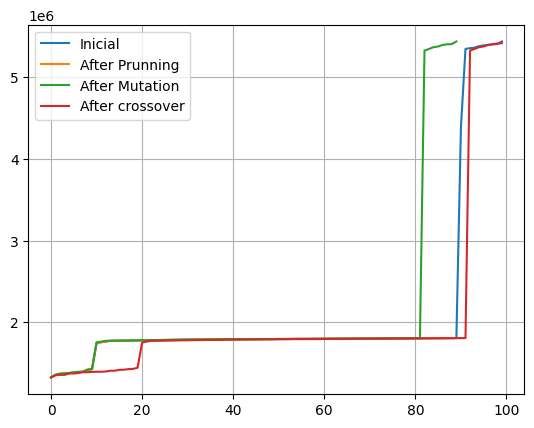

In [106]:
Z=[xi.Z for xi in P]
print('Mejor Z original: ', min(Z))
plt.plot(sorted(Z), label='Inicial')
P=prunning(P, Np)
Z=[xi.Z for xi in P]
print('Mejor Z Luego de prunning: ', min(Z))
plt.plot(sorted(Z), label='After Prunning')
P=mutacion(P, Nm, 1000)
Z=[xi.Z for xi in P]
print('Mejor Z luego de mutación: ', min(Z))
plt.plot(sorted(Z), label='After Mutation')
P=reproduccion(P, Nc)
Z=[xi.Z for xi in P]
print('Mejor Z luego de reproducción: ', min(Z))
plt.plot(sorted(Z), label='After crossover')
plt.legend()

plt.grid()

Mejor valor de Z: 1331263.2252485503
Mejor solucion inicial:  1331263.2252485503
Iteración:  20 , Mejor valor:  1284776.0500922454

KeyboardInterrupt: 

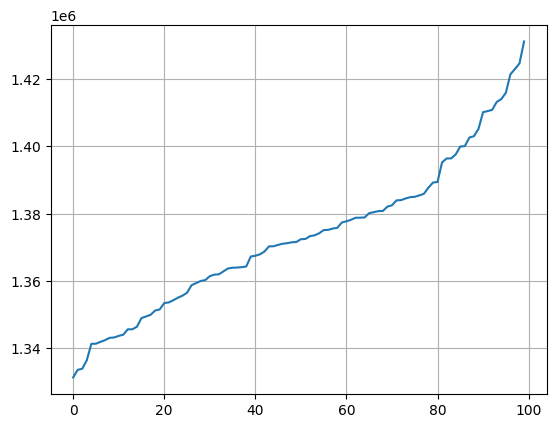

In [107]:
#Definiciones del algoritmo genético
m=100 #Tamaño de la población
Np=int(m/10) #Dimensión del prunning
Nm=int(m/10) #Dimensión de la mutación
Nc=int(m/10) #Dimensión de la reproducción

P=[solucion() for i in range(m)]
Z=[xi.Z for xi in P] #Valor de fitness de todas las soluciones
plt.plot(sorted(Z))
plt.grid()
print('Mejor valor de Z:',min(Z))

from tqdm import tqdm
NumIter=50000
print('Mejor solucion inicial: ',min(Z))
best=solucion(P[np.argmin(Z)].X)
error=[best.Z]
mejor=solucion(P[np.argmin(Z)].X)
#print('Mejor solución al incio: ', best.Z)
dv=10
for i in range(NumIter):
  P=prunning(P, Np)
  P=mutacion(P, Nm,10)
  P=reproduccion(P, Nc)
  Z=[xi.Z for xi in P]
  if(i%dv==0):
    print('\rIteración: ',i,', Mejor valor: ',best.Z, end='')
  mejor=solucion(P[np.argmin(Z)].X)
  if(mejor.Z<best.Z):
    best=solucion(mejor.X)
    print('\rIteración: ',i,', Mejor valor: ',best.Z, end='')
  error.append(best.Z)

  if(best.Z==0):
    print('Solución encontrada')
    break
#plt.plot(sorted(Z), label='Final')
#plt.legend()
#plt.xlabel('Población')
#plt.ylabel('Fitness')
#plt.grid()
plt.figure()
plt.plot(error)
plt.xlabel('Iteraciones')
plt.ylabel('Fitness')
plt.grid()

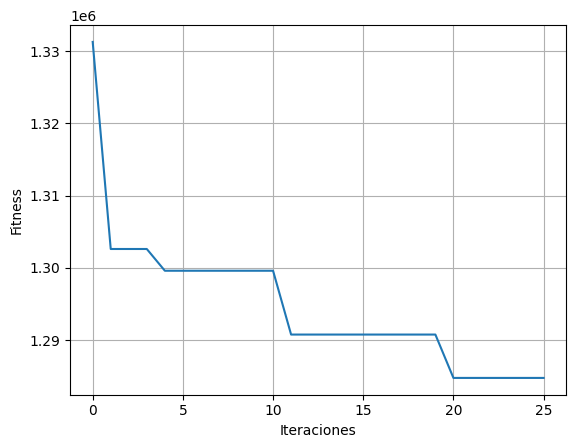

In [108]:
plt.figure()
plt.plot(error)
plt.xlabel('Iteraciones')
plt.ylabel('Fitness')
plt.grid()